In [1]:
import sys

from sympy.abc import alpha

sys.path.append('../src')

%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import pandas as pd
from collections import deque

import seaborn as sns
import matplotlib.pyplot as plt
from structure_learning.approximators import StructureMCMC
from structure_learning.data import SyntheticDataset, Data
from structure_learning.distributions import Distribution, OPAD
from structure_learning.data_structures import DAG
from structure_learning.scores import BGeScore

np.random.seed(100)

Testing new class Node - NIW_BGe_GlobalPrior_Node

In [233]:
synthetic_data = SyntheticDataset(num_nodes=5, num_obs=500, node_labels=[chr(ord('a') + i) for i in range(5)], degree=2)
scaled_data = synthetic_data.data.standardise()


00000 10010 10000 10000 01100


In [234]:
# Implementing a new class Node - Testing

bge = BGeScore(scaled_data)
bge_result = bge.compute(synthetic_data.graph, compute_full_posterior=True)

bge_result




{'score': np.float64(-1293.187211191673),
 'parameters': {'a': {'score': np.float64(111.87910839508564),
   'node_idx': 0,
   'parents': [1, 2, 3],
   'node_label': 'a',
   'parent_label': [np.str_('b'), np.str_('c'), np.str_('d')],
   'posterior': {'sigma2_shape': 253.0,
    'sigma2_scale': np.float64(9.0433132413458),
    'muN_node': np.float64(-5.672995894292217e-17),
    'muN_parents': b   -3.013779e-17
    c   -4.963871e-17
    d   -2.304655e-17
    dtype: float64,
    'beta_mean': array([-0.22537673, -0.42452511,  0.38429538]),
    'chol_parent_T': array([[ 22.34949664,   0.        ,   0.        ],
           [ 19.12316346,  11.56739466,   0.        ],
           [-20.85369045,   0.10174615,   8.03823626]]),
    'kappa_N': 501}},
  'b': {'score': np.float64(-247.35366550782362),
   'node_idx': 1,
   'parents': [4],
   'node_label': 'b',
   'parent_label': [np.str_('e')],
   'posterior': {'sigma2_shape': 252.0,
    'sigma2_scale': np.float64(38.21914489662677),
    'muN_node': np.

In [235]:
from structure_learning.data_structures.node import NIW_BGe_GlobalPrior_Node
target_col = 'a'
parents = synthetic_data.graph.find_parents(target_col)

niw_node = NIW_BGe_GlobalPrior_Node(
    data=scaled_data,
    parents=parents,
    target_col=target_col,
    rng=np.random.default_rng(123),
)

niw_node.fit()

In [236]:
niw_node.marginal_likelihood()

np.float64(111.87910839508646)

In [237]:
print(f'NIW node and BGeScore for node {target_col} is identical: {np.allclose(niw_node.marginal_likelihood(), bge_result['parameters'][target_col]['score'])}')

NIW node and BGeScore for node a is identical: True


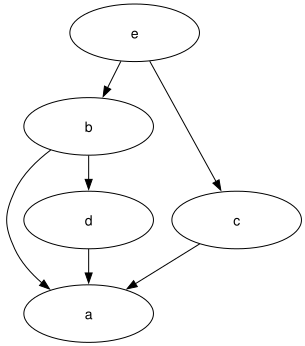

In [238]:
synthetic_data.graph.plot()


# Tests:

1. Given a DAG, how BGeScore changes with the level of missingness, and what happens to the score after missing  in the data.

|## Test 1: BGeScore with missingness
1. Single node missingness => See effect only on a leaf node
2. Single node missingness => See effect only on a root node
3. Single node missingness => See effect only on a non-leaf node
4. Multiple node missingness

In [239]:
if synthetic_data.graph.has_cycle(synthetic_data.graph):
    raise ValueError("Graph is not a DAG")
topological_order = synthetic_data.graph.topological_sort()
topological_order

['e', 'b', 'c', 'd', 'a']

In [240]:
leaf_node = topological_order[-1]



In [241]:
missing_rate = 0.1

missing_mask = np.random.rand(*(scaled_data[leaf_node].shape)) < missing_rate

simulating_data_with_missingness = scaled_data.__copy__()
simulating_data_with_missingness.values[leaf_node][missing_mask] = np.nan


C:\Users\161342\AppData\Local\Temp\ipykernel_33968\4218513209.py:6: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  simulating_data_with_missingness.values[leaf_node][missing_mask] = np.nan


In [242]:
simulating_data_with_missingness.values.isna().sum(axis=0)

a    48
b     0
c     0
d     0
e     0
dtype: int64

In [243]:
score_struct = BGeScore(scaled_data)
score_struct.compute(synthetic_data.graph)['score']


np.float64(-1293.187211191673)

In [244]:
score_struct_missing = BGeScore(simulating_data_with_missingness.values.dropna())
score_struct_missing.compute(synthetic_data.graph)['score']

np.float64(-1181.6258487582545)

In [245]:
def sample_missing_values(
    data: Data,
    graph: DAG,
    models: dict,
    random_state=None,
):
    """
    Sample missing values from node-wise conditional models following
    the DAG's topological order.

    Existing observed values are never overwritten.

    Parameters
    ----------
    data : pd.DataFrame
        Data with columns corresponding to graph nodes.

    graph : nx.DiGraph
        Directed acyclic graph.

    models : dict
        Mapping:
            node -> fitted model

        Each model is expected to provide:
            model.sample(parent_values, rng=...)

        where parent_values is a DataFrame of shape
            (n_samples, n_parents)

        For root nodes, parent_values will have zero columns.

    random_state : int or None
        Random seed.

    Returns
    -------
    pd.DataFrame
        Copy of data with sampleable missing values filled.
    """

    if DAG.has_cycle(graph):
        # TODO: this might not be neccesary in the future if we can guarantee that the graph is a DAG.
        raise ValueError("graph must be a DAG")

    rng = np.random.default_rng(random_state)

    topo_order = graph.topological_sort()

    for node in topo_order:

        parents = list(graph.find_parents(node))

        # Only sampling missing data - TODO: missing data per node, should be captured in INIT - keep an empty list if no missing data so easy to continue. keep indices instead?
        missing = data[node].isna()

        if not missing.any():
            # print(f"Node {node} has no missing values. Skipping.")
            continue

        # ------------------------------------------------------------
        # Determine which missing observations can actually be sampled
        # ------------------------------------------------------------

        if parents:
            # Parents have already been processed because we're following
            # topological order.
            parents_available = data[parents][missing].notna().all(axis=1)

            rows_to_sample = parents_available.index[parents_available]

        else:
            # Root node: no conditioning variables are required.
            rows_to_sample = data.values.index[missing]

        if len(rows_to_sample) == 0:
            continue

        # ------------------------------------------------------------
        # Sample only the required observations
        # ------------------------------------------------------------

        valid_node_data = Data(data.values[~missing], variables=data.variables)

        BGeNode = NIW_BGe_GlobalPrior_Node(
            data=valid_node_data,
            parents=parents,
            target_col=node,
            rng=rng,
        ).fit()

        samples = BGeNode.predict(data.values.loc[rows_to_sample, parents])

        # Assign only sampled values
        res = data.values.copy()
        node_idx = res.columns.get_loc(node)
        res.iloc[rows_to_sample, node_idx] = samples.flatten()


    return Data(res, variables=data.variables)

In [246]:
from structure_learning.data_structures.node import NIW_BGe_GlobalPrior_Node

models = {}

for target_col in scaled_data.columns:
    parents = synthetic_data.graph.find_parents(target_col)
    niw_node = NIW_BGe_GlobalPrior_Node(
        data=scaled_data,
        parents=parents,
        target_col=target_col,
        rng=np.random.default_rng(123),
    )

    niw_node.fit()

    models[target_col] = niw_node


In [247]:
resampled_NAN_data = sample_missing_values(simulating_data_with_missingness,  synthetic_data.graph, models)

In [248]:
resampled_NAN_data.values.isna().sum(axis=0)

a    0
b    0
c    0
d    0
e    0
dtype: int64

In [249]:
score_struct_with_resampled_NAN = BGeScore(resampled_NAN_data)
score_struct_with_resampled_NAN.compute(synthetic_data.graph)['score']


np.float64(-1287.874827550641)

In [250]:
type(resampled_NAN_data.values)

pandas.core.frame.DataFrame

C:\Users\161342\AppData\Local\Temp\ipykernel_33968\1529987112.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


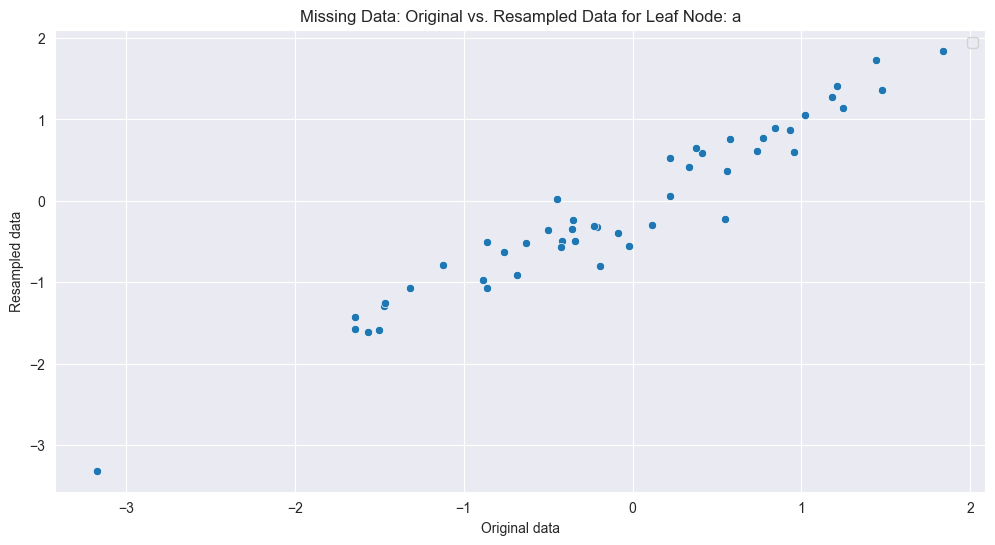

C:\Users\161342\AppData\Local\Temp\ipykernel_33968\1529987112.py:20: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


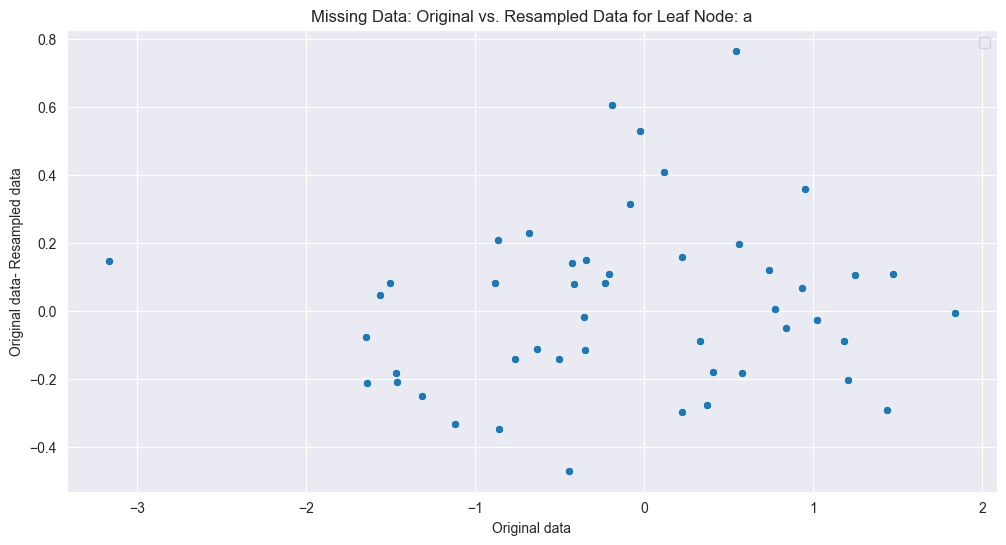

In [251]:
# histogram of the original data and the resampled data for the leaf node - not overlapping
plt.figure(figsize=(12, 6))

sns.scatterplot(x=scaled_data.values.loc[missing_mask, leaf_node], y=resampled_NAN_data.values.loc[missing_mask, leaf_node])

plt.title(f'Missing Data: Original vs. Resampled Data for Leaf Node: {leaf_node}')
plt.xlabel('Original data')
plt.ylabel('Resampled data')
plt.legend()
plt.show()

plt.figure(figsize=(12, 6))

sns.scatterplot(x=scaled_data.values.loc[missing_mask, leaf_node],
                y=scaled_data.values.loc[missing_mask, leaf_node] - resampled_NAN_data.values.loc[missing_mask, leaf_node])

plt.title(f'Missing Data: Original vs. Resampled Data for Leaf Node: {leaf_node}')
plt.xlabel('Original data')
plt.ylabel('Original data- Resampled data')
plt.legend()
plt.show()


In [252]:
NAN_res = []
for _ in range(1000):

    resampled_NAN_data = sample_missing_values(simulating_data_with_missingness,  synthetic_data.graph, models)
    score_struct_with_resampled_NAN = BGeScore(resampled_NAN_data)
    NAN_res.append(score_struct_with_resampled_NAN.compute(synthetic_data.graph)['score'])

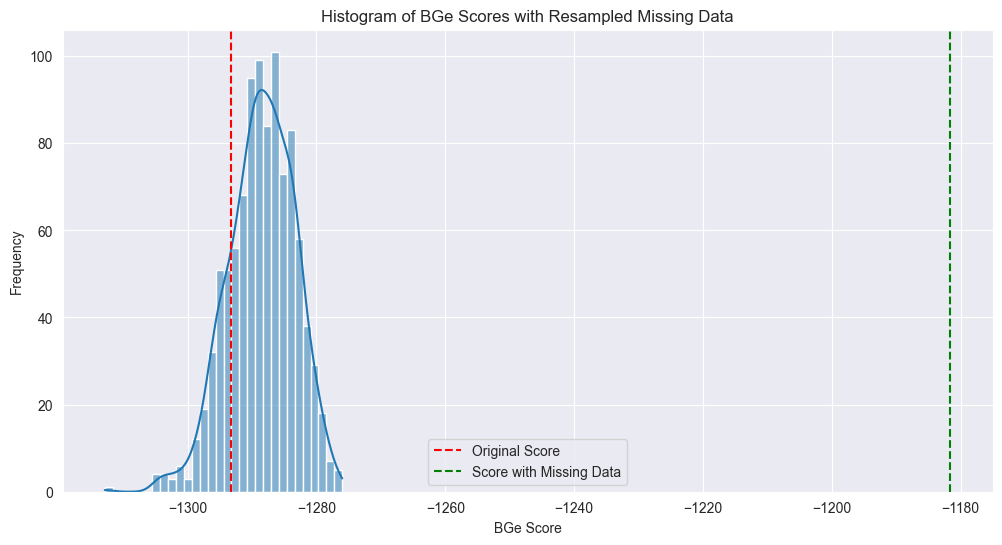

In [253]:
# plot a histogram of the scores with resampled missing data
plt.figure(figsize=(12, 6))
sns.histplot(NAN_res, bins=30, kde=True)
plt.axvline(score_struct.compute(synthetic_data.graph)['score'], color='r', linestyle='--', label='Original Score')
plt.axvline(score_struct_missing.compute(synthetic_data.graph)['score'], color='g', linestyle='--', label='Score with Missing Data')
plt.title('Histogram of BGe Scores with Resampled Missing Data')
plt.xlabel('BGe Score')
plt.ylabel('Frequency')
plt.legend()
plt.show()

In [ ]:
bge_avg = []
bge_std = []

missing_rate_vec = np.linspace(0.01, 0.5, 20)
for missing_rate in missing_rate_vec:
    print(f"Missing rate: {missing_rate:.2f}")
    missing_mask = np.random.rand(*(scaled_data[leaf_node].shape)) < missing_rate
    simulating_data_with_missingness = scaled_data.__copy__()
    simulating_data_with_missingness.values[leaf_node][missing_mask] = np.nan

    NAN_res = []
    for _ in range(1000):

        resampled_NAN_data = sample_missing_values(simulating_data_with_missingness,  synthetic_data.graph, models)
        score_struct_with_resampled_NAN = BGeScore(resampled_NAN_data)
        NAN_res.append(score_struct_with_resampled_NAN.compute(synthetic_data.graph)['score'])

    bge_avg.append(np.mean(NAN_res))
    bge_std.append(np.std(NAN_res))

Missing rate: 0.01


C:\Users\161342\AppData\Local\Temp\ipykernel_33968\837953562.py:9: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  simulating_data_with_missingness.values[leaf_node][missing_mask] = np.nan


Missing rate: 0.04


C:\Users\161342\AppData\Local\Temp\ipykernel_33968\837953562.py:9: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  simulating_data_with_missingness.values[leaf_node][missing_mask] = np.nan


Missing rate: 0.06


C:\Users\161342\AppData\Local\Temp\ipykernel_33968\837953562.py:9: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  simulating_data_with_missingness.values[leaf_node][missing_mask] = np.nan


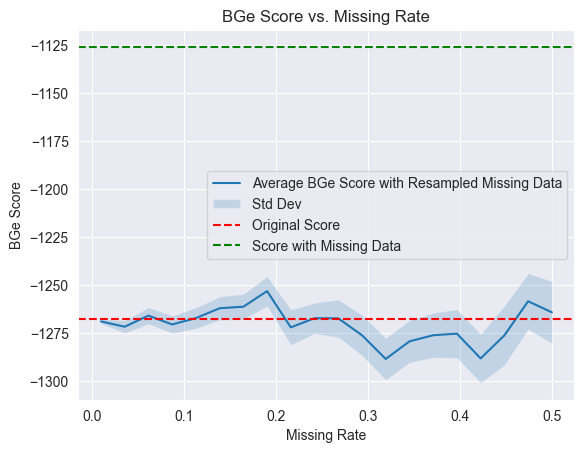

In [232]:
plt.plot(missing_rate_vec, bge_avg, label='Average BGe Score with Resampled Missing Data')
plt.fill_between(missing_rate_vec, np.array(bge_avg) - np.array(bge_std), np.array(bge_avg) + np.array(bge_std), alpha=0.2, label='Std Dev')
plt.axhline(score_struct.compute(synthetic_data.graph)['score'], color='r', linestyle='--', label='Original Score')
plt.axhline(score_struct_missing.compute(synthetic_data.graph)['score'], color='g', linestyle='--', label='Score with Missing Data')
plt.title('BGe Score vs. Missing Rate')
plt.xlabel('Missing Rate')
plt.ylabel('BGe Score')
plt.legend()
plt.show()